In [1]:
import LeafletSC
import sys
import numpy as np
import torch 
import pandas as pd
# still do preprocessing in scipy
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from importlib import reload
# get UMAP
import umap
import LeafletSC

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
reload(factor_model)

2.3.0+cu121
12.1
2.3.0+cu121
12.1


<module 'factor_model' from '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/factor_model.py'>

In [2]:
# published metadata
metacells = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/human_MTG_2018-06-14_samples-columns.csv"
# read in metacells 
cells_pub = pd.read_csv(metacells)
cells_pub.head()

,sample_name,sample_id,sample_type,organism,donor,sex,age_days,brain_hemisphere,brain_region,brain_subregion,...,percent_mt_exon_reads,percent_reads_unique,percent_synth_reads,percent_ecoli_reads,percent_aligned_reads_total,complexity_cg,genes_detected_cpm_criterion,genes_detected_fpkm_criterion,class,cluster
0,F1S4_160106_001_B01,556012415,Nuclei,Homo sapiens,H200.1030,M,19710,L,MTG,L5,...,0.090052,85.573696,0.007535,0.018537,92.418885,0.316637,8635,5253,GABAergic,Inh L4-6 SST B3GAT2
1,F1S4_160106_001_C01,556012410,Nuclei,Homo sapiens,H200.1030,M,19710,L,MTG,L5,...,0.052470,87.619777,0.002790,0.007265,94.001319,0.287989,11697,8246,Glutamatergic,Exc L5-6 RORB TTC12
2,F1S4_160106_001_E01,556012412,Nuclei,Homo sapiens,H200.1030,M,19710,L,MTG,L5,...,0.042946,86.448562,0.004573,0.006413,92.871217,0.280933,12138,8467,Glutamatergic,Exc L5-6 FEZF2 ABO
3,F1S4_160106_001_G01,556012414,Nuclei,Homo sapiens,H200.1030,M,19710,L,MTG,L5,...,0.055851,84.497105,0.006585,0.008131,90.198132,0.293406,12191,8287,Glutamatergic,Exc L5-6 FEZF2 EFTUD1P1
4,F1S4_160106_001_H01,556012409,Nuclei,Homo sapiens,H200.1030,M,19710,L,MTG,L5,...,0.055692,87.014752,0.005061,0.011116,93.460676,0.293106,10535,6922,Glutamatergic,Exc L3-5 RORB ESR1


In [6]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cuda


In [13]:
hypers = {
            "eta" : 1/K, # 1 or 1/K
            "alpha_prior" : 1., 
            "pi_prior" : 1. 
        }

In [32]:
# Append this directory to sys.path
from LeafletSC.clustering.find_intron_clusters import visualize_local_events
from LeafletSC.beta_binomial_mix.modeling import *
from LeafletSC.beta_binomial_mix.calculate_cellstate_consistency import *
from LeafletSC.clustering.load_cluster_data import *
from LeafletSC.utils.helpers import * 
from LeafletSC.utils.visualization import *

In [8]:
# Define path that contains the model input files and append it (input can be a folder with one .h5 file per cell_type for example or one file)
model_input_file="/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/LeafletAnalysis/human_cortex_mtg_leaflet.h5"

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data(
     input_file = model_input_file, max_intron_count=50000, remove_singletons=True, has_genes="yes")

# add cluster information to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# generate torch tensors for sparse data representation 
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

# simplify columns 
simple_data = final_data[["cell_id_index", "Cluster", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

print("The number of junctions is: ", len(junction_ids_conversion))
print("The number of intron clusters observed is: ", len(junction_ids_conversion.Cluster.unique()))
print("The number of genes is: ", len(junction_ids_conversion.gene_id.unique()))
print("The number of cells is: ", len(simple_data.cell_id_index.unique()))

Reading in data from folder ...
Finished reading in data from folder ...
Removing singletons ...
Number of junctions before removing singletons:  69758
Number of junctions after removing singletons:  69758
The number of unique cell types in the data is:  4
The number of unique cells in the data is:  208
The number of unique junctions in the data is:  69759
The maximum junction count was initially:  6106
0
The maximum junction count is now:  6106
The number of junctions in the data is:  69759
The number of cells in the data is:  208
The number of cell types in the data is:  4
The number of cells going into training data is:
208
208
The number of junctions is:  69759
The number of intron clusters observed is:  19285
The number of genes is:  9685
The number of cells is:  208


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/LeafletSC/clustering/load_cluster_data.py:47: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount).to_sparse_csr()


In [9]:
init_labels = cell_ids_conversion["cell_type"]
# Set GAMMA to dummy values based on the initial labels
cell_type_dummy = pd.get_dummies(init_labels)
cell_type_dummy_columns = cell_type_dummy.columns
# make dataframe of cell_type_dummy_columns and index from 0 to len(cell_type_dummy_columns)
cell_type_dummy_df = pd.DataFrame(cell_type_dummy_columns, columns=["cell_type"])
cell_type_dummy_df["cell_type_index"] = range(len(cell_type_dummy_columns))
# we will just save this here for now and run CAVI and map everything back after before doing differential splicing analysis 
cell_type_dummy_df

,cell_type,cell_type_index
0,GABAergic,0
1,Glutamatergic,1
2,Non-neuronal,2
3,no class,3


In [14]:
num_trials = 5 # should also be an argument that gets fed in
num_iters = 100 # should also be an argument that gets fed in
K = 4
print("The K used is: ", K)
results = [ calculate_CAVI(K, my_data, float_type, hypers, init_labels = init_labels, num_iterations = num_iters, fixed_cell_types = True) 
           for t in range(num_trials) ]

The K used is:  4
Initialize VI params
Initializing variational parameters with N = 208 cells and J = 69759 junctions
Initializing cell state proportions with init_labels
Running CAVI with fixed cell types
z and theta will not be updated!
Got the initial ELBO ^
The tolerance is set to  0.001
ELBO converged @ -24051780.0 CAVI iteration # 2 complete
ELBO converged @ -24051780.0 CAVI iteration # 2 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 208 cells and J = 69759 junctions
Initializing cell state proportions with init_labels
Running CAVI with fixed cell types
z and theta will not be updated!
Got the initial ELBO ^
The tolerance is set to  0.001
ELBO converged @ -24051780.0 CAVI iteration # 2 complete
ELBO converged @ -24051780.0 CAVI iteration # 2 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 208 cells and J = 69759 junctions
Initializing cell state proportions with init_labels
Running CAVI with fix

In [15]:
best = np.argmax([ g[-1][-1] for g in results ]) # final ELBO
print(f"The trial with the highest ELBO was {best}")
ALPHA_f, PI_f, GAMMA_f, PHI_f, elbos_all = results[best]
elbos_all = np.array(elbos_all)
elbos_all

The trial with the highest ELBO was 0


array([-1.2621504e+08, -2.4051780e+07, -2.4051780e+07])

In [16]:
cell_type_dummy_df

,cell_type,cell_type_index
0,GABAergic,0
1,Glutamatergic,1
2,Non-neuronal,2
3,no class,3


In [17]:
# let's compare first two cell types 
cell_type1_index = 0
cell_type2_index = 1

In [18]:
juncs_probs = ALPHA_f / (ALPHA_f+PI_f)   
alpha_plus_pi = ALPHA_f+PI_f

juncs_probs.shape

torch.Size([69759, 4])

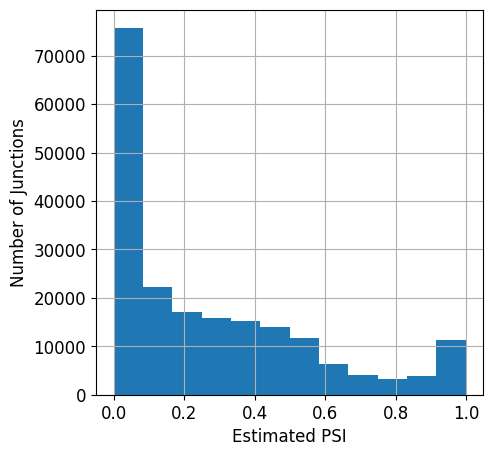

In [19]:
# Create boolean mask from tensor1
mask = alpha_plus_pi >= 10

# Apply the mask to tensor2 to get filtered values
filtered_values = juncs_probs[mask]

plt.figure(figsize=(5, 5))
# Plot the values
plt.hist(filtered_values.numpy(), bins=12)  # Assuming you want a histogram, adjust as needed
plt.xlabel('Estimated PSI', fontsize=12)
# Set y-label with larger font size (if you need it)
plt.ylabel('Number of Junctions', fontsize=12)  
# Increase tick label size
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# add grid 
plt.grid()

In [20]:
juncs_probs_df = pd.DataFrame(juncs_probs, columns = range(K))
juncs_probs_df["junction_id_index"] = junction_ids_conversion.junction_id_index.values
# convert to juncs_probs to pandas dataframe and calculate mean and std across cell states/topics
juncs_probs_df["junction_id"] = junction_ids_conversion.junction_id.values
juncs_probs_df.head()

,0,1,2,3,junction_id_index,junction_id
0,0.989583,0.993506,0.500000,0.886076,0,1_11819554_11822694
1,0.617647,0.595238,0.941176,0.762712,1,1_150150287_150150911
2,0.003497,0.024648,0.007752,0.077143,2,1_150151058_150158818
3,0.283276,0.467186,0.500000,0.537143,3,1_69678478_69760190
4,0.993103,0.960000,0.500000,0.975524,4,1_69838283_69931506


In [22]:
scores_all_juncs = []

for junc_index in range(juncs_probs.shape[0]):
    a = ALPHA_f[junc_index, [cell_type1_index, cell_type2_index]]
    b = PI_f[junc_index, [cell_type1_index, cell_type2_index] ]
    scores_all_juncs.append(score(a, b).item())

# turn scores_all_juncs into dataframe and add junction_id_index as a column
scores_all_juncs_df = pd.DataFrame(scores_all_juncs, columns = ["score"])
scores_all_juncs_df["junction_id_index"] = junction_ids_conversion.junction_id_index.values

In [23]:
# Compute the logistic score
scores_all_juncs_df["logistic_score"] = 1 / (1 + np.exp(-scores_all_juncs_df["score"].values))

# Compute the Bayesian q-value for FDR
scores_all_juncs_df["q_value"] = 1 - scores_all_juncs_df["logistic_score"].values 
scores_all_juncs_df["significance"] = np.where(scores_all_juncs_df["q_value"].values < 0.01, "yes", "no")

In [24]:
scores_all_juncs_df["significance"].value_counts()

significance
no     50769
yes    18990
Name: count, dtype: int64

In [25]:
# merge scores_all_juncs_df with junction_ids_conversion to get gene_id and junction_id 
scores_all_juncs_df = scores_all_juncs_df.merge(junction_ids_conversion, on="junction_id_index")
scores_all_juncs_df.sort_values(by="score", ascending=False).head(10)

,score,junction_id_index,logistic_score,q_value,significance,junction_id,Cluster,gene_id
24997,415.507568,24997,1.0,0.0,yes,10_77019099_77027822,11448,ENSG00000156113.25
7045,405.874512,7045,1.0,0.0,yes,8_103766537_103885297,9402,ENSG00000176406.25
2335,364.155762,2335,1.0,0.0,yes,8_103819629_103885297,9402,ENSG00000176406.25
8201,349.722168,8201,1.0,0.0,yes,15_24955062_24962113,15010,ENSG00000128739.23
480,320.983398,480,1.0,0.0,yes,2_71433283_71434741,2140,ENSG00000075292.19
8388,306.741699,8388,1.0,0.0,yes,16_5867335_6316994,15815,ENSG00000078328.23
7718,292.519531,7718,1.0,0.0,yes,12_56160320_56161386,12857,ENSG00000092841.19
16463,280.945801,16463,1.0,0.0,yes,20_47347926_47356656,19671,ENSG00000101040.20
3612,188.843750,3612,1.0,0.0,yes,14_100857388_100860690,14609,ENSG00000214548.18
26912,182.218628,26912,1.0,0.0,yes,10_18150975_18401923,11027,ENSG00000165995.24


In [26]:
cell_type1 = cell_type_dummy_df[cell_type_dummy_df["cell_type_index"]==cell_type1_index]["cell_type"].values[0]
cell_type2 = cell_type_dummy_df[cell_type_dummy_df["cell_type_index"]==cell_type2_index]["cell_type"].values[0]
cell_types = [cell_type1, cell_type2]
print(cell_types)

['GABAergic', 'Glutamatergic']


In [80]:
junc = 5865
clust = get_cluster(junc, junction_ids_conversion)
gene = get_gene(junc, junction_ids_conversion)
print(f"The cluster is {clust} and the gene is {gene}")

The cluster is 3537 and the gene is ENSG00000174501.15


In [81]:
simple_data_human = final_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

cell_type
Glutamatergic    92
GABAergic        49
Name: count, dtype: int64


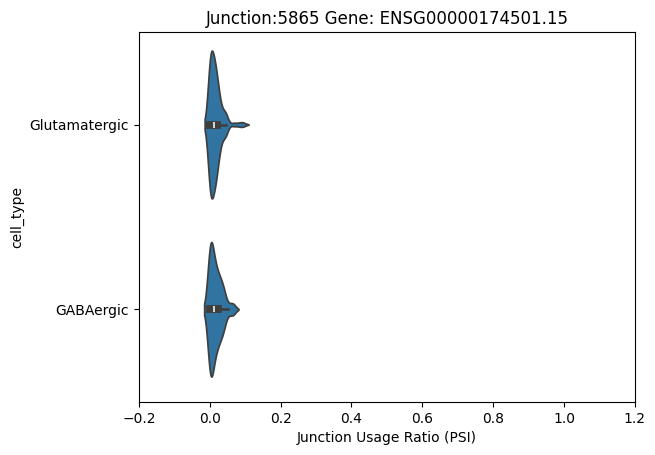

In [82]:
quick_junc_plot(junc, simple_data_human, gene_name=True, cell_types=cell_types)

In [70]:
scores_all_juncs_df[scores_all_juncs_df["gene_id"] == "ENSG00000174501.15"].sort_values("score", ascending=False)

,score,junction_id_index,logistic_score,q_value,significance,junction_id,Cluster,gene_id
850,76.500000,850,1.000000,0.000000,yes,2_95882374_95882468,3537,ENSG00000174501.15
9742,73.875000,9742,1.000000,0.000000,yes,2_95958785_95962351,3537,ENSG00000174501.15
21512,58.125000,21512,1.000000,0.000000,yes,2_95889994_95891831,3537,ENSG00000174501.15
14145,41.062500,14145,1.000000,0.000000,yes,2_95882497_95886047,3537,ENSG00000174501.15
865,39.625000,865,1.000000,0.000000,yes,2_95893724_95894212,3537,ENSG00000174501.15
...,...,...,...,...,...,...,...,...
907,-2.187500,907,0.100879,0.899121,no,2_95927286_95927380,3537,ENSG00000174501.15
844,-2.228516,844,0.097219,0.902781,no,2_95860074_95867439,3534,ENSG00000174501.15
906,-2.250000,906,0.095349,0.904651,no,2_95925547_95927213,3537,ENSG00000174501.15
5865,-2.312500,5865,0.090093,0.909907,no,2_95958663_95958756,3537,ENSG00000174501.15


<Axes: xlabel='juncratio', ylabel='Count'>

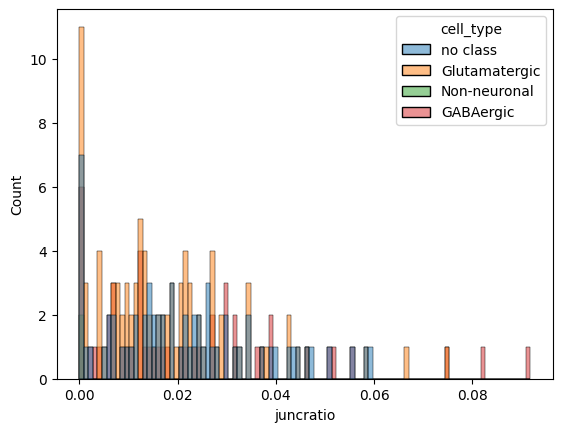

In [68]:
junc_dat = simple_data_human[simple_data_human["junction_id_index"] == 865]

# make histogram of junc_dat juncratio values and colour by cell_Type 
sns.histplot(junc_dat, x="juncratio", hue="cell_type", bins=100)

cell_type
Glutamatergic    12052
GABAergic         6419
Name: count, dtype: int64


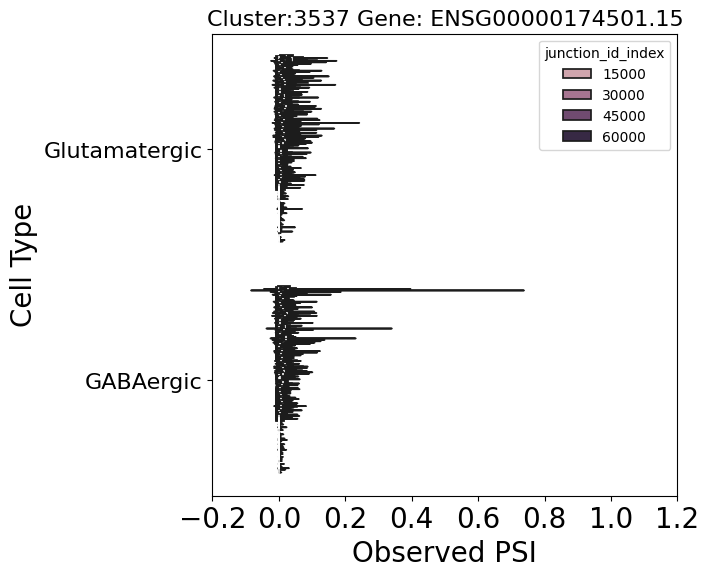

In [69]:
quick_clust_plot(clust, simple_data_human, gene_name=True, cell_types=cell_types)

In [60]:
# summarize total number of junctions that are significantly differentially spliced between the two
# cell types of interest and also the number of unique genes they belong to

print("The number of junctions that are significantly differentially spliced between the two cell types is: ", scores_all_juncs_df["significance"].value_counts()["yes"])
print("The number of unique genes that these junctions belong to is: ", scores_all_juncs_df[scores_all_juncs_df["significance"]=="yes"]["gene_id"].nunique())

The number of junctions that are significantly differentially spliced between the two cell types is:  18990
The number of unique genes that these junctions belong to is:  6103


In [61]:
# print the gene that has the most number of junctions that are significantly differentially spliced between the two cell types
gene_counts = scores_all_juncs_df[scores_all_juncs_df["significance"]=="yes"]["gene_id"].value_counts()

# print the top 5 genes with the most DS junctions
print("The top 5 genes with the most number of junctions that are significantly differentially spliced between the two cell types are: ")
print(gene_counts.head(5))

The top 5 genes with the most number of junctions that are significantly differentially spliced between the two cell types are: 
gene_id
ENSG00000174501.15    61
ENSG00000135976.21    51
ENSG00000224078.15    47
ENSG00000259905.7     31
ENSG00000197969.14    24
Name: count, dtype: int64


In [ ]:
# ENSG00000174501.15 = ion channel activity 